# Proyecto Data Science
## Modelado del comportamiento de Bitcoin mediante variables macro-financieras

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"

params = {
    "vs_currency": "usd",
    "days": 365
}

response = requests.get(url,params=params)

In [3]:
response.status_code

200

In [4]:
data = response.json()

In [5]:
type(data)

dict

In [6]:
data.keys()

dict_keys(['prices', 'market_caps', 'total_volumes'])

In [7]:
data['prices'][:5]

[[1747180800000, 104184.49039270742],
 [1747267200000, 103594.42575090709],
 [1747353600000, 103708.85136423641],
 [1747440000000, 103556.03493982446],
 [1747526400000, 103212.36483885496]]

In [8]:
prices_df = pd.DataFrame(
    data['prices'],
    columns=['timestamp', 'prices']
)

In [9]:
prices_df.head()

,timestamp,prices
0,1747180800000,104184.490393
1,1747267200000,103594.425751
2,1747353600000,103708.851364
3,1747440000000,103556.034940
4,1747526400000,103212.364839


In [10]:
prices_df['timestamp'] = pd.to_datetime(
    prices_df['timestamp'],
    unit='ms'
)

In [11]:
prices_df.head()

,timestamp,prices
0,2025-05-14,104184.490393
1,2025-05-15,103594.425751
2,2025-05-16,103708.851364
3,2025-05-17,103556.034940
4,2025-05-18,103212.364839


In [12]:
prices_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  366 non-null    datetime64[ms]
 1   prices     366 non-null    float64       
dtypes: datetime64[ms](1), float64(1)
memory usage: 5.8 KB


In [13]:
## Creación de retorno
prices_df['return'] = prices_df['prices'].pct_change()

In [14]:
prices_df.head()

,timestamp,prices,return
0,2025-05-14,104184.490393,NaN
1,2025-05-15,103594.425751,-0.005664
2,2025-05-16,103708.851364,0.001105
3,2025-05-17,103556.034940,-0.001474
4,2025-05-18,103212.364839,-0.003319


In [15]:
prices_df['return'].describe()

count    365.000000
mean      -0.000498
std        0.022090
min       -0.141018
25%       -0.012717
50%       -0.000306
75%        0.011127
max        0.122034
Name: return, dtype: float64

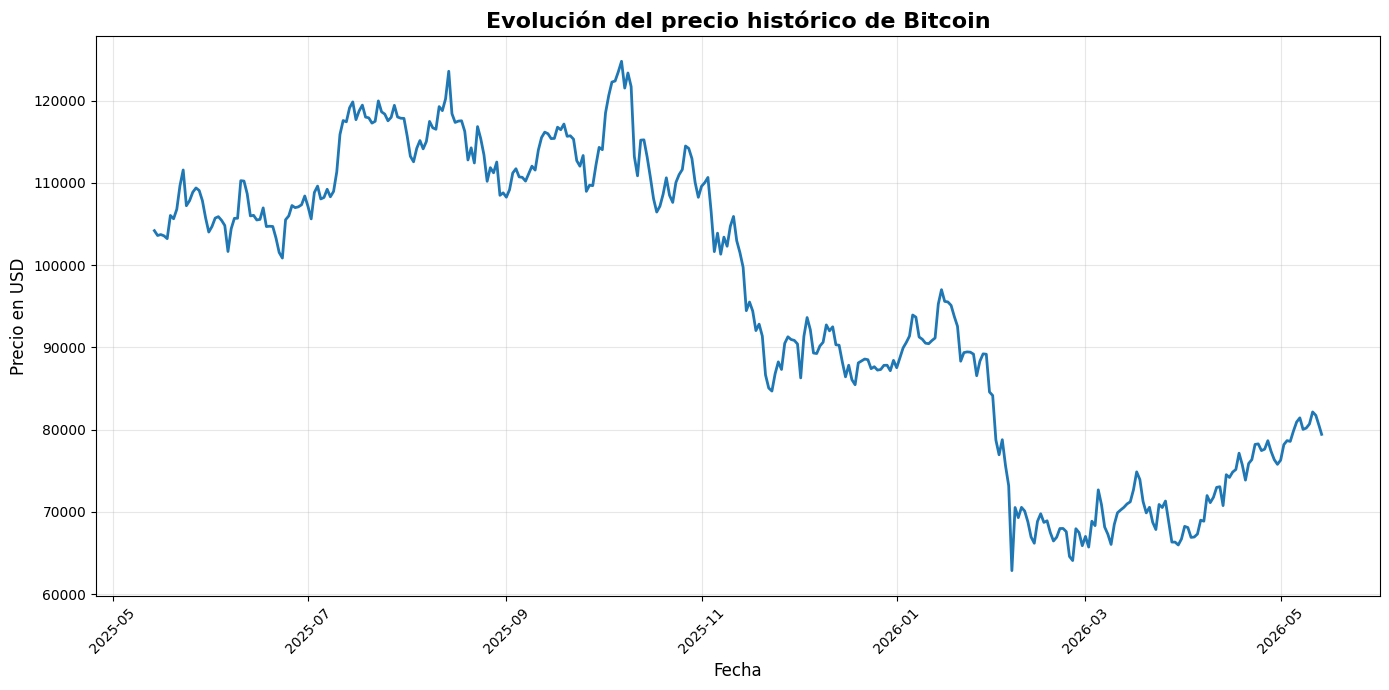

In [16]:
plt.figure(figsize=(14, 7))

plt.plot(
    prices_df['timestamp'],
    prices_df['prices'],
    linewidth=2
)

plt.title(
    'Evolución del precio histórico de Bitcoin',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio en USD', fontsize=12)

plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

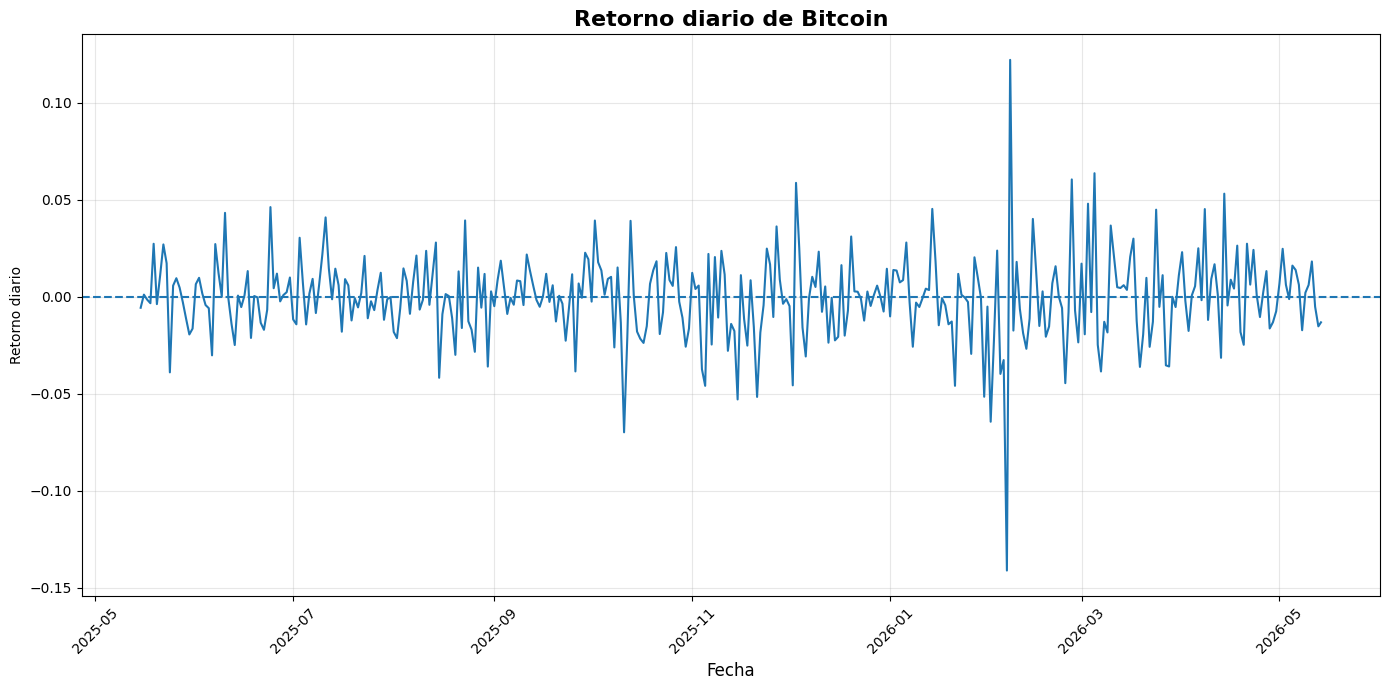

In [17]:
plt.figure(figsize=(14,7))

plt.plot(
    prices_df['timestamp'],
    prices_df['return']
)

plt.title(
    'Retorno diario de Bitcoin',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Retorno diario')

plt.axhline(
    y=0,
    linestyle='--'
)

plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [18]:
prices_df['volatilidad_7d'] = (
    prices_df['return'].rolling(window=7).std()
)

In [19]:
prices_df.head()

,timestamp,prices,return,volatilidad_7d
0,2025-05-14,104184.490393,NaN,NaN
1,2025-05-15,103594.425751,-0.005664,NaN
2,2025-05-16,103708.851364,0.001105,NaN
3,2025-05-17,103556.034940,-0.001474,NaN
4,2025-05-18,103212.364839,-0.003319,NaN


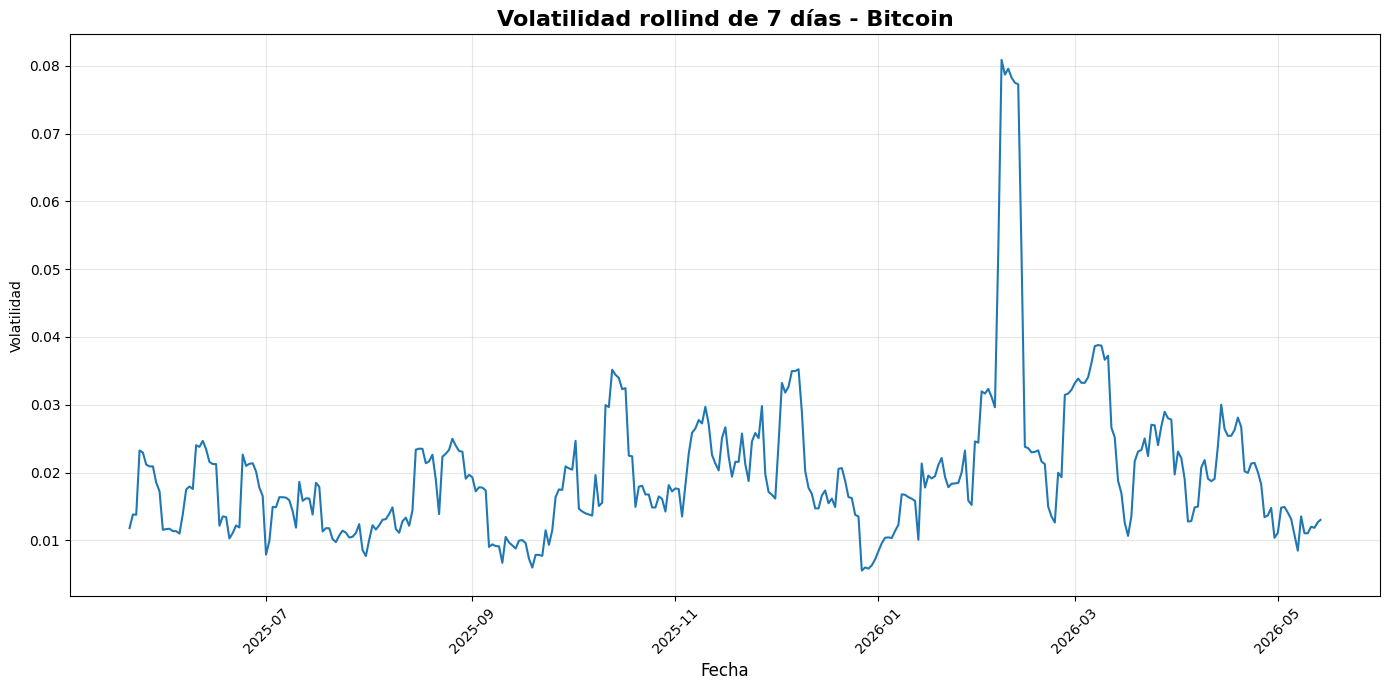

In [20]:
plt.figure(figsize=(14,7))

plt.plot(
    prices_df['timestamp'],
    prices_df['volatilidad_7d']
)

plt.title(
    'Volatilidad rollind de 7 días - Bitcoin',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Volatilidad')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
prices_df['ma_7d'] = (
    prices_df['prices'].rolling(window=7).mean()
)

In [22]:
prices_df.head()

,timestamp,prices,return,volatilidad_7d,ma_7d
0,2025-05-14,104184.490393,NaN,NaN,NaN
1,2025-05-15,103594.425751,-0.005664,NaN,NaN
2,2025-05-16,103708.851364,0.001105,NaN,NaN
3,2025-05-17,103556.034940,-0.001474,NaN,NaN
4,2025-05-18,103212.364839,-0.003319,NaN,NaN


In [23]:
prices_df.head(15)

,timestamp,prices,return,volatilidad_7d,ma_7d
0,2025-05-14,104184.490393,NaN,NaN,NaN
1,2025-05-15,103594.425751,-0.005664,NaN,NaN
2,2025-05-16,103708.851364,0.001105,NaN,NaN
3,2025-05-17,103556.034940,-0.001474,NaN,NaN
4,2025-05-18,103212.364839,-0.003319,NaN,NaN
5,2025-05-19,106030.637683,0.027306,NaN,NaN
6,2025-05-20,105629.415804,-0.003784,NaN,104273.745825
7,2025-05-21,106786.719958,0.010956,0.011806,104645.492906
8,2025-05-22,109665.863716,0.026962,0.013813,105512.841186
9,2025-05-23,111560.356938,0.017275,0.013771,106634.484840


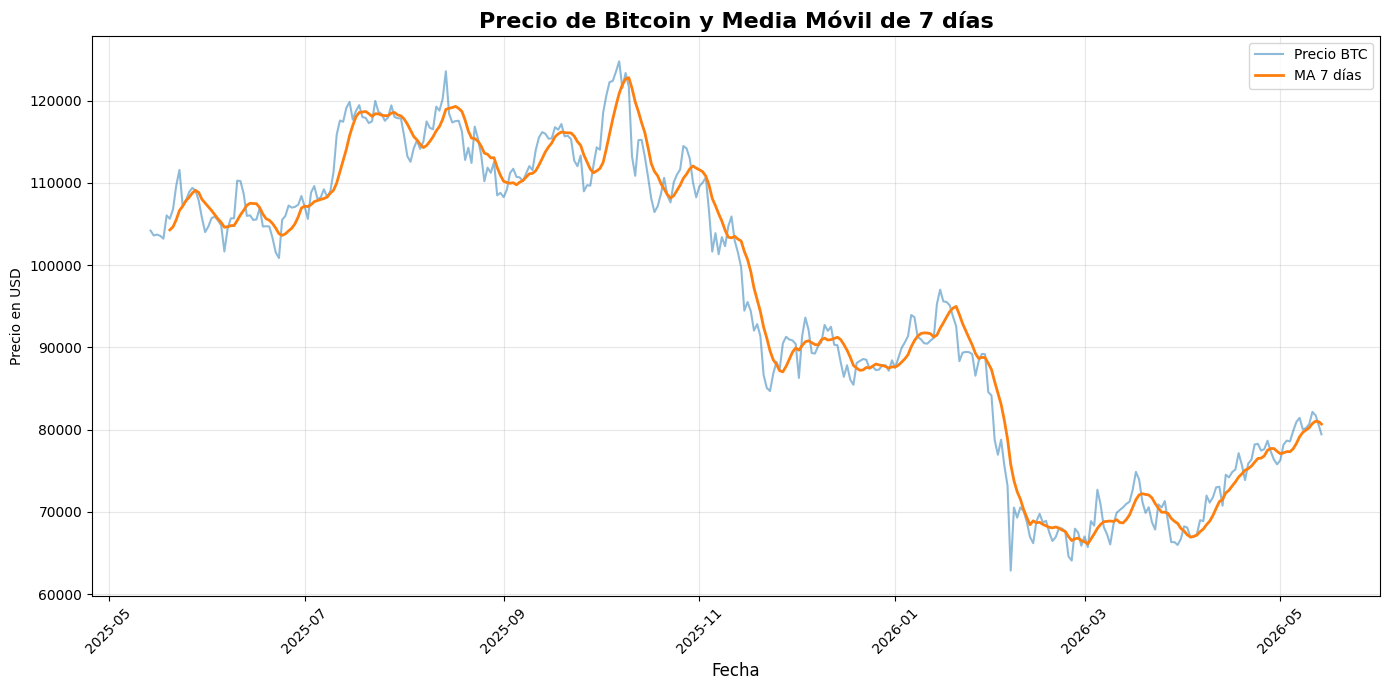

In [24]:
plt.figure(figsize=(14,7))

plt.plot(
    prices_df['timestamp'],
    prices_df['prices'],
    label='Precio BTC',
    alpha=0.5
)

plt.plot(
    prices_df['timestamp'],
    prices_df['ma_7d'],
    linewidth=2,
    label='MA 7 días'
)

plt.title(
    'Precio de Bitcoin y Media Móvil de 7 días',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio en USD')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
prices_df[[
    'prices',
    'return',
    'volatilidad_7d',
    'ma_7d'
]].describe()

,prices,return,volatilidad_7d,ma_7d
count,366.000000,365.000000,359.000000,360.000000
mean,95757.700535,-0.000498,0.019864,95816.019396
std,17768.427900,0.022090,0.010738,17727.034560
min,62853.690384,-0.141018,0.005542,66096.294393
25%,78736.308442,-0.012717,0.013423,78716.516554
50%,101087.611471,-0.000306,0.017904,101169.615190
75%,110961.632438,0.011127,0.023257,111360.872991
max,124773.508231,0.122034,0.080860,122782.867695
